# 03 - Descriptive analysis of the network

Now that we have a graph, we want a structural baseline before calculating more specialized scores or simulating failures. We measure its size, density, degree distribution, connected components, articulation points, and bridges. The component results tell us how connected it is before any removal, while articulation points and bridges locate places with no topological alternative at all.

**Question for this notebook:** *How sparse and fragmented is the scheduled-service network, and how many individual stops or segments can split a component when removed?*

## Input

* `outputs/nb/02_graph_construction/nodes.csv` - one row per active stop, with `stop_id, stop_name, lat, lon, region, metro`.
* `outputs/nb/02_graph_construction/edges.csv` - one row per directed segment `from_stop, to_stop, trip_frequency`.

Both files come from notebook 02, so we do not need to read the raw 816 MB stop-times table again.

## Output

Everything is written under `outputs/nb/03_descriptive_analysis/`:

* `network_summary.json` - all the main statistics in a single dictionary.
* `tables/network_summary.csv` - the same statistics as a one-row table.
* `tables/degree_distribution.csv` - the number of stops at each degree value.
* `tables/component_sizes.csv` - the size of every connected component.
* `tables/articulation_points.csv` - every articulation point, with name / coordinates / region / degree.
* `tables/bridges.csv` - every bridge edge, with the endpoint names and trip frequency.
* `tables/stops_by_region.csv` - the number of stops per administrative region.
* `figures/degree_distribution.png`, `figures/components_summary_bar.png`, `figures/top_articulation_points.png`, `figures/network_overview_map.png`, `figures/stops_by_region.png`.

This notebook only writes the tables, figures, and summary listed above inside its own stage folder.

## 1. Setting up the working environment

We start with the shared path and dependency setup. `_ensure(...)` installs only missing imports, and `find_repo_root()` searches upward for the GTFS directory or clones the project into `/content` in a fresh Colab session. The cell changes to the repository root and defines `REPO`, `DATA`, and `OUT`, which anchor every path below.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Libraries, stage folders, and tunable constants

This cell imports pandas and NumPy for tables and arrays, NetworkX for graph algorithms, and Matplotlib/Seaborn for plotting. It creates this stage's `tables` and `figures` directories and points `GRAPH_STAGE` at the outputs from notebook 02.

The constants mostly control display: how many components and articulation points we show and the saved figure resolution. Connected components, articulation points, and bridges use linear graph traversals and are inexpensive at roughly 30 thousand nodes and 52 thousand edges. `FIG_DPI` mainly affects the time and file size of the all-stop map.

In [2]:
# --- Libraries and stage folders ------------------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn')

import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)

PREV = OUT / '02_graph_construction'      # read-only: artifacts of notebook 02
STAGE = OUT / '03_descriptive_analysis'   # everything this notebook produces
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants ----------------------------------------------------
FIG_DPI = 150        # figure resolution; drop to 90 for faster, smaller files
TOP_N = 20           # rows shown in every top-N table / bar chart
MAP_ALPHA = 0.55     # point transparency on the ~30k-point geographic scatter
DEG_HIST_BINS = 60   # bins of the linear degree histogram

print('graph input    :', PREV)
print('this stage     :', STAGE)

graph input    : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction
this stage     : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/03_descriptive_analysis


## 3. Handling Hebrew labels

Some plots use Hebrew stop names. This Matplotlib build handles the bidirectional ordering of raw Hebrew correctly, so we do not pre-reorder the strings. The helper keeps `fix_he()` as a no-op, selects a font with Hebrew glyphs, removes a stale text patch if one exists in the current kernel, and disables scientific offset labels. We want this set before creating any figure so labels behave consistently.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# Pre-reordering with python-bidi would reverse it a second time, so fix_he stays a no-op
# and only a Hebrew-capable font is selected. A build without native bidi handling would
# need get_display; this build does not.
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # Remove a bidi patch if the current kernel contains one, so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Loading the graph produced in notebook 02

We rebuild the graph from notebook 02's portable `nodes.csv` and `edges.csv` files rather than depending on a particular NetworkX pickle version. `find_artifact()` searches the stage directory recursively, then stops with a clear error if either table is missing. We load identifiers as strings and convert `trip_frequency` to numeric values so edge weights cannot remain accidental text.

In [4]:
# --- Locate the artifacts written by notebook 02 --------------------------
def find_artifact(stage_dir, filename):
    """Return the path of `filename` under a stage folder, or None if absent."""
    if not stage_dir.is_dir():
        return None
    direct = stage_dir / filename
    if direct.exists():
        return direct
    matches = sorted(stage_dir.rglob(filename))
    return matches[0] if matches else None

nodes_path = find_artifact(PREV, 'nodes.csv')
edges_path = find_artifact(PREV, 'edges.csv')
missing = [name for name, p in [('nodes.csv', nodes_path), ('edges.csv', edges_path)] if p is None]
if missing:
    raise FileNotFoundError(
        f"{', '.join(missing)} not found under {PREV} - "
        'run notebook 02_graph_construction first; it writes nodes.csv and edges.csv.'
    )

nodes_df = pd.read_csv(nodes_path, dtype={'stop_id': str}, encoding='utf-8-sig')
edges_df = pd.read_csv(edges_path, dtype={'from_stop': str, 'to_stop': str}, encoding='utf-8-sig')
print(f'nodes: {len(nodes_df):,} rows  <-  {nodes_path}')
print(f'edges: {len(edges_df):,} rows  <-  {edges_path}')
nodes_df.head()

nodes: 30,463 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/nodes.csv
edges: 51,999 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/edges.csv


,stop_id,stop_name,lat,lon,region,metro,stop_use_count
0,38725,ת. רכבת יבנה מערב,31.890700,34.731191,Center,Tel Aviv,1370
1,15582,שד. הסנהדרין/שד. ירושלים,31.887865,34.734514,Center,Tel Aviv,228
2,15746,שד. ירושלים/שד. הסנהדרין,31.887569,34.733548,Center,Tel Aviv,742
3,15725,בית ספר אורמת/נחל חריף,31.894514,34.734783,Center,Tel Aviv,84
4,15416,מחלף בית רבן למזרח,31.819528,34.730697,Center,Tel Aviv,832


## 5. Rebuilding the directed and undirected graph

`edges.csv` stores the directed trip-adjacency graph: `u -> v` means a scheduled trip visits `v` immediately after `u`, and `trip_frequency` counts how often that ordered segment occurs. We reconstruct `D` from those rows. For undirected connectivity we build `G` with one edge per unordered pair and add the two directional weights. This merging is why `G` has slightly fewer edges than `D`.

We add every node first and attach its name, coordinates, region, and metro from `nodes.csv`; then we add edges and weights. `_num()` turns invalid coordinates into `None`, while `_txt()` prevents pandas `NaN` values from becoming the literal string `"nan"`. The printed graph sizes let us compare this reconstruction with the construction summary.

In [5]:
# --- Rebuild the two graph objects ----------------------------------------
def _num(value):
    """Coerce to float; return None for blanks, NaN or non-numeric input."""
    if value is None:
        return None
    try:
        f = float(value)
    except (TypeError, ValueError):
        return None
    return None if not np.isfinite(f) else f


def _txt(value):
    """Coerce to a plain string; NaN and None become an empty string."""
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return ''
    return str(value)


def build_graphs(nodes_df, edges_df):
    """Return (G, D): the undirected projection and the directed trip graph."""
    attr = {}
    for rec in nodes_df.to_dict('records'):
        attr[str(rec.get('stop_id'))] = {
            'stop_name': _txt(rec.get('stop_name')),
            'lat': _num(rec.get('lat')),
            'lon': _num(rec.get('lon')),
            'region': _txt(rec.get('region')),
            'metro': _txt(rec.get('metro')),
        }

    weight_col = next((c for c in ('trip_frequency', 'weight', 'count')
                       if c in edges_df.columns), None)

    D = nx.DiGraph()
    for rec in edges_df.to_dict('records'):
        u, v = str(rec['from_stop']), str(rec['to_stop'])
        D.add_edge(u, v, weight=int(rec[weight_col]) if weight_col else 1)

    # Undirected projection: one edge per unordered pair, weights summed.
    G = nx.Graph()
    for u, v, data in D.edges(data=True):
        if G.has_edge(u, v):
            G[u][v]['weight'] += data['weight']
        else:
            G.add_edge(u, v, weight=data['weight'])

    default = {'stop_name': '', 'lat': None, 'lon': None, 'region': '', 'metro': ''}
    for graph in (G, D):
        for n in graph.nodes():
            graph.nodes[n].update(attr.get(n, default))
    return G, D


G, D = build_graphs(nodes_df, edges_df)
unnamed = sum(1 for n in G.nodes() if not G.nodes[n]['stop_name'])
print(f'undirected G : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'directed   D : {D.number_of_nodes():,} nodes, {D.number_of_edges():,} edges')
print(f'nodes with no name attribute: {unnamed:,}')

undirected G : 30,463 nodes, 51,772 edges
directed   D : 30,463 nodes, 51,999 edges
nodes with no name attribute: 0


## 6. Global descriptive statistics

This cell calculates the baseline measurements we will use throughout the notebook:

* node and edge counts for `G` and `D`;
* undirected density, $2m/[n(n-1)]$, or the share of all possible stop pairs that have a direct segment;
* mean, median, minimum, and maximum degree;
* undirected components and the share of nodes in the largest connected component (LCC);
* weak and strong components of `D`, where a large strong component means most included stops have directed paths both ways;
* articulation points and bridges, whose removal increases the number of connected components.

We convert articulation points to a set before sorting so the count is unambiguous across NetworkX versions. The component and cut-structure algorithms are linear graph traversals, so they complete quickly. We save the resulting dictionary as JSON and as a one-row CSV, then display it for the calculations that follow.

In [6]:
# --- Global descriptive statistics ----------------------------------------
components = sorted(nx.connected_components(G), key=len, reverse=True)
component_sizes = [len(c) for c in components]
largest = component_sizes[0]

# Cut vertices and cut edges: both are linear-time DFS routines.
ap = sorted(set(nx.articulation_points(G)))
br = list(nx.bridges(G))

wcc = list(nx.weakly_connected_components(D))
scc = list(nx.strongly_connected_components(D))

degrees = np.array([d for _, d in G.degree()])

summary = {
    'num_nodes': G.number_of_nodes(),
    'num_edges_undirected': G.number_of_edges(),
    'num_edges_directed': D.number_of_edges(),
    'density': round(nx.density(G), 6),
    'avg_degree': round(float(degrees.mean()), 2),
    'median_degree': float(np.median(degrees)),
    'min_degree': int(degrees.min()),
    'max_degree': int(degrees.max()),
    'num_connected_components': len(components),
    'largest_component_nodes': largest,
    'largest_component_share': round(largest / G.number_of_nodes(), 4),
    'num_weakly_connected': len(wcc),
    'num_strongly_connected': len(scc),
    'largest_scc_nodes': max(len(c) for c in scc),
    'num_articulation_points': len(ap),
    'num_bridges': len(br),
}

with open(STAGE / 'network_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
pd.DataFrame([summary]).to_csv(TABLES / 'network_summary.csv', index=False, encoding='utf-8-sig')

print('saved:', STAGE / 'network_summary.json')
pd.DataFrame({'metric': list(summary.keys()), 'value': list(summary.values())})

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/03_descriptive_analysis/network_summary.json


,metric,value
0,num_nodes,30463.000000
1,num_edges_undirected,51772.000000
2,num_edges_directed,51999.000000
3,density,0.000112
4,avg_degree,3.400000
5,median_degree,3.000000
6,min_degree,1.000000
7,max_degree,62.000000
8,num_connected_components,12.000000
9,largest_component_nodes,30237.000000


## 7. The degree distribution

A node's undirected degree is its number of distinct neighboring stops, regardless of how many trips use those connections. We count how many stops have each degree and draw two views:

* The top panel keeps degree on a linear x-axis but uses a log y-axis so the large degree-2 bar does not hide the tail.
* The bottom panel places positive degree and count values on log-log axes and adds an ordinary least-squares line in log space. A roughly straight section is consistent with a heavy tail, but this slope is only descriptive. It is not a validated power-law fit; that would need tail selection, maximum-likelihood estimation, and a goodness-of-fit test.

We save the exact degree counts and print the fitted slope, intercept, and $R^2$ so the visual impression can be checked numerically.

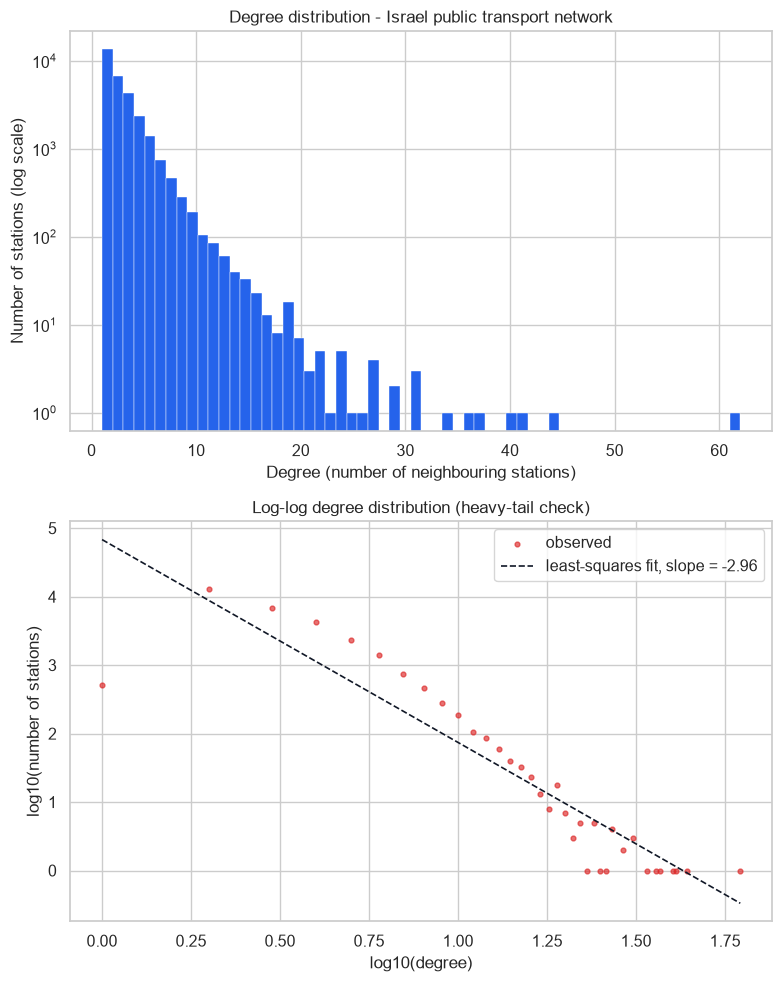

degree range: 1 to 62, mean 3.40, median 3
stations with degree <= 2: 13,609 (44.7%)
log-log least-squares slope: -2.96


In [7]:
# --- Degree distribution: histogram + log-log view -------------------------
deg_counts = pd.Series(degrees).value_counts().sort_index()
deg_counts = deg_counts[deg_counts.index > 0]

deg_table = pd.DataFrame({'degree': deg_counts.index.astype(int),
                          'num_stations': deg_counts.to_numpy().astype(int)})
deg_table['share'] = (deg_table['num_stations'] / len(degrees)).round(5)
deg_table.to_csv(TABLES / 'degree_distribution.csv', index=False, encoding='utf-8-sig')

x = np.log10(deg_table['degree'].to_numpy(dtype=float))
y = np.log10(deg_table['num_stations'].to_numpy(dtype=float))
slope, intercept = np.polyfit(x, y, 1)

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].hist(degrees, bins=DEG_HIST_BINS, color='#2563eb', edgecolor='white', linewidth=0.3)
axes[0].set_yscale('log')
axes[0].set_xlabel('Degree (number of neighbouring stations)')
axes[0].set_ylabel('Number of stations (log scale)')
axes[0].set_title('Degree distribution - Israel public transport network')

axes[1].scatter(x, y, s=12, color='#dc2626', alpha=0.65, label='observed')
axes[1].plot(x, slope * x + intercept, color='#111827', linewidth=1.2, linestyle='--',
             label=f'least-squares fit, slope = {slope:.2f}')
axes[1].set_xlabel('log10(degree)')
axes[1].set_ylabel('log10(number of stations)')
axes[1].set_title('Log-log degree distribution (heavy-tail check)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'degree_distribution.png', dpi=FIG_DPI)
plt.show()

print(f'degree range: {degrees.min()} to {degrees.max()}, mean {degrees.mean():.2f}, median {np.median(degrees):.0f}')
print(f'stations with degree <= 2: {(degrees <= 2).sum():,} ({(degrees <= 2).mean():.1%})')
print(f'log-log least-squares slope: {slope:.2f}')

## 8. Connected components

We sort every connected component of `G` by size, save the full list, and plot the largest ones. A component is a maximal group of stops joined by some undirected path. The logarithmic y-axis is necessary because the giant component is thousands of times larger than the small disconnected clusters. This view tells us whether later fragmentation should be measured on the whole graph or interpreted relative to an already dominant LCC.

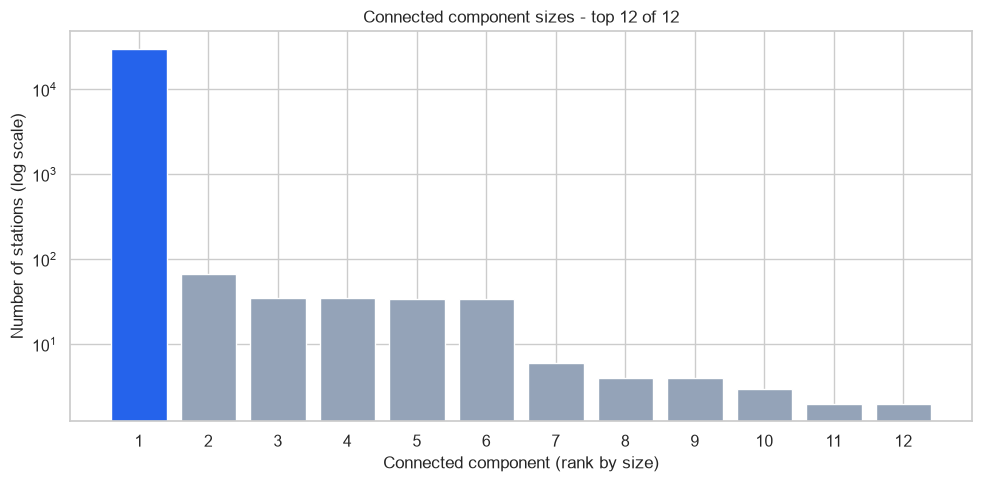

12 components; largest holds 30,237 stations (99.26%)


,component_rank,num_stations,share
0,1,30237,0.992581
1,2,67,0.002199
2,3,35,0.001149
3,4,35,0.001149
4,5,34,0.001116
5,6,34,0.001116
6,7,6,0.000197
7,8,4,0.000131
8,9,4,0.000131
9,10,3,0.000098


In [8]:
# --- Connected component sizes --------------------------------------------
comp_table = pd.DataFrame({'component_rank': range(1, len(component_sizes) + 1),
                           'num_stations': component_sizes})
comp_table['share'] = (comp_table['num_stations'] / G.number_of_nodes()).round(6)
comp_table.to_csv(TABLES / 'component_sizes.csv', index=False, encoding='utf-8-sig')

top_components = component_sizes[:TOP_N]
bar_colors = ['#2563eb' if i == 0 else '#94a3b8' for i in range(len(top_components))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(top_components) + 1), top_components, color=bar_colors)
ax.set_yscale('log')
ax.set_xticks(range(1, len(top_components) + 1))
ax.set_xlabel('Connected component (rank by size)')
ax.set_ylabel('Number of stations (log scale)')
ax.set_title(f'Connected component sizes - top {len(top_components)} of {len(component_sizes)}')
plt.tight_layout()
plt.savefig(FIGURES / 'components_summary_bar.png', dpi=FIG_DPI)
plt.show()

print(f'{len(component_sizes)} components; largest holds '
      f"{largest:,} stations ({largest / G.number_of_nodes():.2%})")
comp_table.head(TOP_N)

## 9. Articulation points and bridges

Here we turn the articulation-point and bridge sets into usable tables.

* An articulation point is a stop whose removal increases the component count.
* A bridge is an undirected scheduled-service connection whose removal increases the component count.

For articulation points we attach name, coordinates, region, metro, degree, and weighted degree, then sort by degree. For bridges we attach both endpoint names and the combined frequency, then sort by weight. A bridge is a topological single connection, not necessarily a literal single road or track, and its frequency still measures scheduled supply rather than passenger impact. We save both complete tables.

In [9]:
# --- Export cut vertices and cut edges -------------------------------------
ap_df = pd.DataFrame([{
    'stop_id': n,
    'stop_name': G.nodes[n]['stop_name'],
    'lat': G.nodes[n]['lat'],
    'lon': G.nodes[n]['lon'],
    'region': G.nodes[n]['region'],
    'metro': G.nodes[n]['metro'],
    'degree': G.degree(n),
} for n in ap])
ap_df = ap_df.sort_values('degree', ascending=False).reset_index(drop=True)
ap_df.to_csv(TABLES / 'articulation_points.csv', index=False, encoding='utf-8-sig')

br_df = pd.DataFrame([{
    'from_stop': u,
    'to_stop': v,
    'from_name': G.nodes[u]['stop_name'],
    'to_name': G.nodes[v]['stop_name'],
    'trip_frequency': int(G[u][v].get('weight', 1)),
} for u, v in br])
br_df = br_df.sort_values('trip_frequency', ascending=False).reset_index(drop=True)
br_df.to_csv(TABLES / 'bridges.csv', index=False, encoding='utf-8-sig')

print(f'articulation points : {len(ap_df):,} '
      f"({len(ap_df) / G.number_of_nodes():.2%} of all stations)")
print(f'bridges             : {len(br_df):,} '
      f"({len(br_df) / G.number_of_edges():.2%} of all undirected edges)")
print('\nHighest-traffic bridges:')
display(br_df.head(TOP_N))
print('Highest-degree articulation points:')
ap_df.head(TOP_N)

articulation points : 900 (2.95% of all stations)
bridges             : 971 (1.88% of all undirected edges)

Highest-traffic bridges:


,from_stop,to_stop,from_name,to_name,trip_frequency
0,44793,44795,אוניברסיטת חיפה,טכניון מרכז,2402
1,44795,44798,טכניון מרכז,מרכזית המפרץ,2402
2,23299,23298,ת. רכבת קרית אריה,ת. רכבת קרית אריה,1809
3,11448,48932,מסוף חומת שמואל/אליהו קורן,תחנה תפעולית/היציאה מחניון חומת שמואל,1672
4,10532,48933,רב החובל/אדם,תחנה תפעולית/חניון תלפיות מזרח,1575
5,49466,10576,מסוף הר נוף/כנפי נשרים,מסוף הר נוף/בית הדפוס,1306
6,49109,49149,יהודית,שאול המלך,1218
7,49145,49146,ביאליק,בן גוריון,1218
8,49093,49150,ארלוזורוב,אבא הלל,1218
9,49149,49093,שאול המלך,ארלוזורוב,1218


Highest-degree articulation points:


,stop_id,stop_name,lat,lon,region,metro,degree
0,41133,מחלף חמד,31.801002,35.124540,Jerusalem,Jerusalem,62
1,9048,בן גוריון/שערי ירושלים,31.791535,35.196465,Jerusalem,Jerusalem,41
2,10775,גשר המיתרים/שד' הרצל,31.787162,35.199533,Jerusalem,Jerusalem,37
3,12975,מחלף לה גווארדייה,32.059454,34.786354,Center,Tel Aviv,34
4,13246,בית ספר הולץ/חיל השריון,32.046238,34.783261,Center,Tel Aviv,31
5,13322,המסגר/הרכב,32.063660,34.785580,Center,Tel Aviv,27
6,9553,גשר המיתרים/שד' הרצל,31.787322,35.199369,Jerusalem,Jerusalem,22
7,13356,דרך קיבוץ גלויות/כביש 1,32.046861,34.784605,Center,Tel Aviv,20
8,27623,מרכז רפואי סורוקה/אוניברסיטת בן גוריון,31.259220,34.798363,South,Beer Sheva,20
9,14355,מחלף מורשה,32.123726,34.854708,Center,Tel Aviv,20


## 10. Which stops are the most important articulation points?

An articulation point only tells us that some split occurs; it does not tell us how large the separated part is. As a first prioritization, we plot the top cut vertices by degree. A degree-2 cut vertex often sits along a thin branch, while a high-degree cut vertex also connects many distinct neighbors. The horizontal chart uses Hebrew stop names and saves the selected IDs and degrees visually, but we do not treat degree alone as the amount of damage caused by removal.

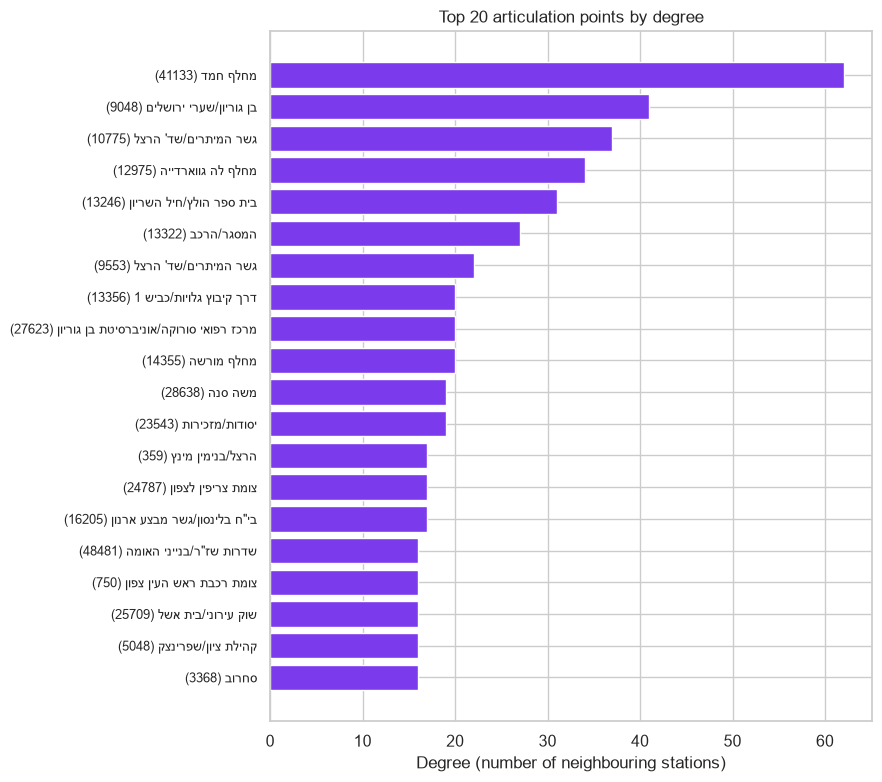

In [10]:
# --- Top articulation points by degree -------------------------------------
top_ap = ap_df.head(TOP_N).iloc[::-1]   # reversed so the largest ends up on top
labels = [f'{name} ({sid})' for name, sid in zip(top_ap['stop_name'], top_ap['stop_id'])]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(range(len(top_ap)), top_ap['degree'].to_numpy(), color='#7c3aed')
ax.set_yticks(range(len(top_ap)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Degree (number of neighbouring stations)')
ax.set_title(f'Top {len(top_ap)} articulation points by degree')
plt.tight_layout()
plt.savefig(FIGURES / 'top_articulation_points.png', dpi=FIG_DPI)
plt.show()

## 11. Geographic overview of the network

We plot every node with finite longitude and latitude, using color and point size for degree. This lets us compare high-degree areas with the coastal, Jerusalem, and Negev geography. It is a plain coordinate scatter rather than a map projection, so we use `1 / cos(mean latitude)` as a visual aspect correction.

The coordinate mask checks for non-null, finite numbers explicitly. Truth-value checks are unsafe here because `0.0` is false while `NaN` is truthy. The colorbar provides the degree scale, and the figure is saved as a geographic overview rather than used for distance measurement.

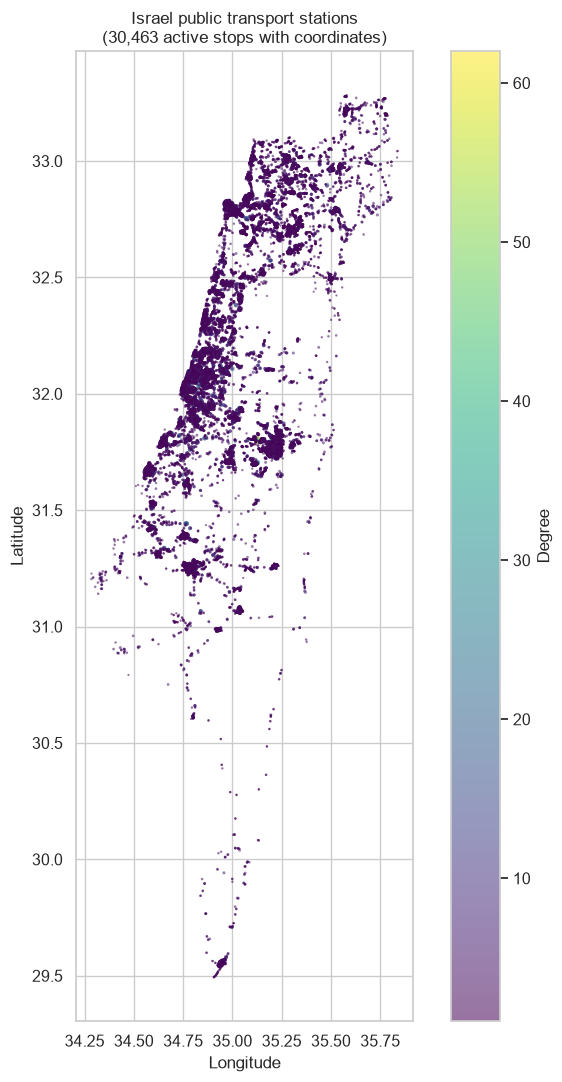

stations with coordinates: 30,463 of 30,463


In [11]:
# --- Network overview map (lat/lon scatter) --------------------------------
def has_coords(data):
    """True only when both coordinates are present and finite (0.0 included)."""
    lat, lon = data.get('lat'), data.get('lon')
    return lat is not None and lon is not None and np.isfinite(lat) and np.isfinite(lon)

coord_nodes = [(n, d) for n, d in G.nodes(data=True) if has_coords(d)]
if not coord_nodes:
    raise ValueError('No station carries usable coordinates - check nodes.csv from notebook 02.')

lats = [d['lat'] for _, d in coord_nodes]
lons = [d['lon'] for _, d in coord_nodes]
degs = [G.degree(n) for n, _ in coord_nodes]
max_deg = max(degs)
sizes = [2 + 30 * (d / max_deg) for d in degs]

fig, ax = plt.subplots(figsize=(8, 11))
sc = ax.scatter(lons, lats, c=degs, s=sizes, cmap='viridis', alpha=MAP_ALPHA, linewidths=0)
plt.colorbar(sc, ax=ax, label='Degree')
ax.set_aspect(1 / np.cos(np.deg2rad(float(np.mean(lats)))))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Israel public transport stations\n'
             f'({len(coord_nodes):,} active stops with coordinates)')
plt.tight_layout()
plt.savefig(FIGURES / 'network_overview_map.png', dpi=FIG_DPI)
plt.show()

print(f'stations with coordinates: {len(coord_nodes):,} of {G.number_of_nodes():,}')

## 12. Stops by region

Finally we count active graph nodes by the coarse `region` label created in notebook 01. This is both a numeric version of the map and a check that the attribute survived graph construction and CSV reconstruction. The code sizes the color palette from the number of observed categories and annotates every bar. These are coordinate-derived analysis regions, not administrative districts.

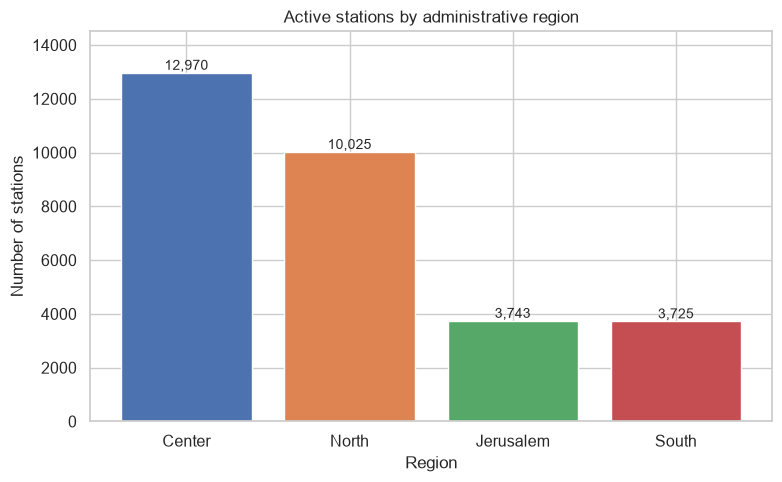

,region,num_stations,share
0,Center,12970,0.4258
1,North,10025,0.3291
2,Jerusalem,3743,0.1229
3,South,3725,0.1223


In [12]:
# --- Stations per region ---------------------------------------------------
region_counts = (pd.Series([G.nodes[n]['region'] or 'Unknown' for n in G.nodes()])
                 .value_counts())
region_table = region_counts.rename_axis('region').reset_index(name='num_stations')
region_table['share'] = (region_table['num_stations'] / G.number_of_nodes()).round(4)
region_table.to_csv(TABLES / 'stops_by_region.csv', index=False, encoding='utf-8-sig')

palette = sns.color_palette('deep', len(region_counts))
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([str(r) for r in region_counts.index], region_counts.to_numpy(), color=palette)
ax.set_xlabel('Region')
ax.set_ylabel('Number of stations')
ax.set_title('Active stations by administrative region')
for bar, val in zip(bars, region_counts.to_numpy()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:,}', ha='center', va='bottom', fontsize=10)
ax.margins(y=0.12)
plt.tight_layout()
plt.savefig(FIGURES / 'stops_by_region.png', dpi=FIG_DPI)
plt.show()

region_table

## Conclusions

The graph is large but extremely sparse: about 30,463 active stops and 51,772 undirected connections give density near 0.0001 and mean degree around 3.4. Most stops have only a few distinct neighbors—the median degree is 3—even when many scheduled trips reuse those edges. That shape is consistent with a geographic corridor network rather than a graph where any node can connect freely to any other.

It is not perfectly connected at baseline, but one component dominates. There are about 12 connected components and the largest contains roughly 99.3% of all nodes. We therefore need to distinguish later between losing already separate tiny clusters and actual fragmentation of the giant component.

The degree counts are strongly right-skewed: degree 2 is common, while a small set of transfer stops has dozens of neighbors. The log-log plot and fitted line are consistent with a heavy tail, but we do not have enough evidence here to call the network scale-free. The OLS line is a visual summary, not a formal power-law test.

There are roughly 900 articulation points, about 3% of nodes, and 971 bridges, under 2% of undirected edges. These are genuine topological single points of failure, but the label covers very different situations. Many are low-degree branch connections that may separate only a few stops, while the high-degree cut vertices deserve closer attention. The tables preserve the complete sets for that follow-up.

The largest strongly connected component contains 28,863 stops, so most of the main network has directed return paths. The directed graph has 51,999 edges and the undirected projection has 51,772, which means exact reverse edges between the same stop IDs are rare. We should not read that as mostly one-way service because opposite directions often use separate platform IDs. The map and region counts show strong concentration in the Center and coastal corridor, with much thinner service in the south.

These conclusions are purely topological and supply-based. An articulation point says removal changes reachability, not how many people are affected; degree counts distinct neighboring stops, not travel time or demand. The next measurements need to add path position and service frequency before we decide which of these structurally special stops are actually the strongest candidates for criticality.